<div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 50%, #6b8dd6 100%);
            padding: 40px 30px; border-radius: 16px; text-align: center;
            color: white; box-shadow: 0 10px 30px rgba(0,0,0,0.25);">

  <h1 style="color: white; margin: 0; font-size: 2.6em; letter-spacing: 1px;
             text-shadow: 2px 2px 8px rgba(0,0,0,0.35);">
    📈 Stock Price Forecasting with LSTM
  </h1>

  <p style="color: white; font-size: 1.15em; text-align: center; margin-top: 12px; opacity: 0.95;">
    A beginner-friendly journey from raw prices → to a working prediction
  </p>

</div>

<div style="display: flex; gap: 16px; align-items: center;
            background: #f0f7ff; padding: 18px 22px; border-radius: 12px;
            border-left: 6px solid #1e88e5;">

  <div style="font-size: 2.2em;">🎯</div>
  <div style="color: #0d47a1;">
    <b>What this notebook is</b><br>
    A hands-on, visual, no-jargon introduction to <b>time series forecasting
    with LSTMs</b>. We start from the absolute basics and finish with an
     prediction <i>inside</i> the notebook.
  </div>
</div>

<br>

<div style="display: flex; gap: 16px; align-items: center;
            background: #fff8e1; padding: 18px 22px; border-radius: 12px;
            border-left: 6px solid #f9a825;">

  <div style="font-size: 2.2em;">⚠️</div>
  <div style="color: #5d4037;">
    <b>Please read this</b><br>
    Stock prices are extremely noisy and difficult to predict. This notebook
    is for <b>learning</b>, not for real trading. By the end, you'll see
    <i>exactly why</i> even a well-trained model struggles here.
  </div>
</div>

<br>

---

### 🧠 The Two Big Ideas

Before we touch any code, let's plant two mental anchors. Everything else
in this notebook builds on these.

<table style="width:100%; border-collapse: separate; border-spacing: 16px 0;">
  <tr>
    <td style="width:50%; vertical-align: top;
               background: #fafafa; border-radius: 12px; padding: 20px;
               border-top: 4px solid #2a5298;">
      <h4 style="margin-top:0;">📊 Time Series</h4>
      Data collected in order over time. Yesterday's price influences today's.
      Order <b>matters</b>.
    </td>
    <td style="width:50%; vertical-align: top;
               background: #fafafa; border-radius: 12px; padding: 20px;
               border-top: 4px solid #2a5298;">
      <h4 style="margin-top:0;">🧠 LSTM</h4>
      A neural network with <b>memory</b>. It reads sequences step by step
      and remembers what's important.
    </td>
  </tr>
</table>

### ⏳ Part 1 — What is a Time Series?

**A time series is data collected in order, over time.** That's it.

<table style="width:100%; border-collapse: separate; border-spacing: 14px 0;">
  <tr>
    <td style="width:33%; vertical-align: top; text-align: center;
               background: #e3f2fd; padding: 20px; border-radius: 12px;">
      <div style="font-size: 2.4em;">🌡️</div>
      <b>Temperature</b><br>
      <span style="font-size: 0.9em; color: #444;">Every hour, every day</span>
    </td>
    <td style="width:33%; vertical-align: top; text-align: center;
               background: #f3e5f5; padding: 20px; border-radius: 12px;">
      <div style="font-size: 2.4em;">❤️</div>
      <b>Heart Rate</b><br>
      <span style="font-size: 0.9em; color: #444;">Every second, non-stop</span>
    </td>
    <td style="width:33%; vertical-align: top; text-align: center;
               background: #fff3e0; padding: 20px; border-radius: 12px;">
      <div style="font-size: 2.4em;">📈</div>
      <b>Stock Price</b><br>
      <span style="font-size: 0.9em; color: #444;">Every trading day, at close</span>
    </td>
  </tr>
</table>

<br>

<div style="background: #e8f5e9; padding: 16px 20px; border-radius: 10px;
            border-left: 6px solid #43a047; color: #1b5e20;">
  <b>🎯 Forecasting</b> = given the <i>past</i>, guess the <i>future</i>.
  Nothing more, nothing less.
</div>

<br>

### 🚫 The Problem with Normal Neural Networks

A regular neural network treats every input as **independent**. It has **no memory**.

<table style="width:100%; border-collapse: collapse; font-size: 0.95em;">
  <tr style="background: #eceff1;">
    <th style="padding: 12px; text-align: left;">What we show it</th>
    <th style="padding: 12px; text-align: left;">What it thinks</th>
  </tr>
  <tr>
    <td style="padding: 12px; border-bottom: 1px solid #ddd;">
      Day 1 price: <b>\$150</b>
    </td>
    <td style="padding: 12px; border-bottom: 1px solid #ddd;">
      "Okay, a number."
    </td>
  </tr>
  <tr>
    <td style="padding: 12px; border-bottom: 1px solid #ddd;">
      Day 2 price: <b>\$152</b>
    </td>
    <td style="padding: 12px; border-bottom: 1px solid #ddd;">
      "Okay, another number. No idea Day 1 existed."
    </td>
  </tr>
  <tr style="background: #ffebee;">
    <td style="padding: 12px;">
      😵 <b>The order is lost!</b>
    </td>
    <td style="padding: 12px;">
      But for stocks, <b>order is everything</b>.
    </td>
  </tr>
</table>

<br>

<div style="background: #fff3e0; padding: 16px 20px; border-radius: 10px;
            border-left: 6px solid #ef6c00; color: #4e342e;">
  <b>💡 The fix:</b> we need a model with <b>memory</b> — one that reads
  data step-by-step and remembers what came before.
</div>

<br>

---

### 🧠 Part 2 — What is an LSTM?

**LSTM = Long Short-Term Memory.**
It's a special neural network designed to **remember sequences**.

<br>

### 📓 The Notepad Analogy

Imagine you're reading a book **one word at a time**. You keep a mental
notepad of what matters so far. Every new word, you do three things:

<table style="width:100%; border-collapse: separate; border-spacing: 14px 0;">
  <tr>
    <td style="width:33%; vertical-align: top; text-align: center;
               background: #ffebee; padding: 20px; border-radius: 12px;
               border-top: 4px solid #e53935;">
      <div style="font-size: 2.2em;">🗑️</div>
      <b style="color: #b71c1c;">Forget</b><br>
      <span style="font-size: 0.9em;">Erase what's no longer relevant.</span>
    </td>
    <td style="width:33%; vertical-align: top; text-align: center;
               background: #e8f5e9; padding: 20px; border-radius: 12px;
               border-top: 4px solid #43a047;">
      <div style="font-size: 2.2em;">✍️</div>
      <b style="color: #1b5e20;">Write</b><br>
      <span style="font-size: 0.9em;">Note what matters from the new word.</span>
    </td>
    <td style="width:33%; vertical-align: top; text-align: center;
               background: #e3f2fd; padding: 20px; border-radius: 12px;
               border-top: 4px solid #1e88e5;">
      <div style="font-size: 2.2em;">📤</div>
      <b style="color: #0d47a1;">Output</b><br>
      <span style="font-size: 0.9em;">Send the result to the next step.</span>
    </td>
  </tr>
</table>

<br>

<div style="text-align: center; padding: 10px;">
  <img src="https://upload.wikimedia.org/wikipedia/commons/3/3b/The_LSTM_cell.png"
       alt="Simplified LSTM Cell Diagram"
       style="border-radius: 10px; box-shadow: 0 4px 14px rgba(0,0,0,0.15); max-width: 70%;"/>
  <p style="font-size: 0.85em; color: #666; margin-top: 8px;">
    One LSTM cell. Those three "gates" inside are exactly the forget / write / output steps.
  </p>
</div>

<br>

### 🔁 Now Stretch It Across Time

The same cell is reused **once per day**. Each time, it passes its
"notepad" (called the **cell state**) to the next step.

<div style="text-align: center; padding: 10px;">
  <img src="https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/RNN-unrolled.png"
       alt="Unrolled LSTM Sequence Diagram"
       style="border-radius: 10px; box-shadow: 0 4px 14px rgba(0,0,0,0.15); max-width: 95%;"/>
  <p style="font-size: 0.85em; color: #666; margin-top: 8px;">
    The same LSTM cell "unrolled" over time. It reads Day 1, then Day 2,
    then Day 3… updating its memory at every step.
  </p>
</div>

<br>

<div style="background: #e8eaf6; padding: 16px 20px; border-radius: 10px;
            border-left: 6px solid #3949ab; color: #1a237e;">
  <b>📖 In plain English:</b> An LSTM is a neural network that reads a
  sequence one step at a time, keeps a "memory" of what mattered so far,
  and uses that memory to make a prediction.
</div>

<br>

---

### ⚖️ LSTM vs. Plain RNN — Why LSTM Wins Here

<table style="width:100%; border-collapse: collapse; font-size: 0.95em;">
  <tr style="background: #263238; color: white;">
    <th style="padding: 12px; text-align: left;">Model</th>
    <th style="padding: 12px; text-align: left;">Memory Span</th>
    <th style="padding: 12px; text-align: left;">Stock Use</th>
  </tr>
  <tr style="background: #fafafa;">
    <td style="padding: 12px; border-bottom: 1px solid #ddd;">
      <b>Plain RNN</b>
    </td>
    <td style="padding: 12px; border-bottom: 1px solid #ddd;">
      Very short — forgets long-ago info
    </td>
    <td style="padding: 12px; border-bottom: 1px solid #ddd;">
      ❌ Struggles
    </td>
  </tr>
  <tr style="background: #e8f5e9;">
    <td style="padding: 12px;">
      <b>LSTM</b>
    </td>
    <td style="padding: 12px;">
      Long — remembers 50+ steps back
    </td>
    <td style="padding: 12px;">
      ✅ Works well
    </td>
  </tr>
</table>

<br>

---

<div style="background: linear-gradient(135deg, #2a5298 0%, #1e3c72 100%);
            padding: 22px 26px; border-radius: 14px; color: white;
            box-shadow: 0 6px 18px rgba(0,0,0,0.25);">
  <h3 style="color: white; margin-top: 0;">🎬 Our Plan in One Line</h3>
  <p style="font-size: 1.05em; margin-bottom: 0;">
    Feed the LSTM the <b>last 60 closing prices</b> →
    predict the <b>next day's closing price</b>.
  </p>
</div>

# 1. Import Libraries

In [2]:
# ============================================================
# All our imports in one place
# ============================================================

import numpy as np                      # numbers & arrays
import pandas as pd                     # data tables
import yfinance as yf                   # stock data
import matplotlib.pyplot as plt         # charts
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Make charts look a bit nicer
plt.style.use('seaborn-v0_8-darkgrid')

# Reproducibility — same results every run
np.random.seed(42)

print("Libraries loaded ✅")

Libraries loaded ✅


# 2. Loading Stock Data


### 🔎 What is a Ticker?

Every publicly traded stock has a short **ticker symbol** — a code the
market uses to identify it. Think of it as a stock's username.

<table style="width:100%; border-collapse: separate; border-spacing: 12px 0;">
  <tr>
    <td style="width:25%; text-align: center; background: #fafafa;
               padding: 16px; border-radius: 10px;
               border-top: 3px solid #1e88e5;">
      <div style="font-size: 1.6em;">🍎</div>
      <b>AAPL</b><br>
      <span style="font-size: 0.85em; color: #555;">Apple</span>
    </td>
    <td style="width:25%; text-align: center; background: #fafafa;
               padding: 16px; border-radius: 10px;
               border-top: 3px solid #43a047;">
      <div style="font-size: 1.6em;">🪟</div>
      <b>MSFT</b><br>
      <span style="font-size: 0.85em; color: #555;">Microsoft</span>
    </td>
    <td style="width:25%; text-align: center; background: #fafafa;
               padding: 16px; border-radius: 10px;
               border-top: 3px solid #e53935;">
      <div style="font-size: 1.6em;">🚗</div>
      <b>TSLA</b><br>
      <span style="font-size: 0.85em; color: #555;">Tesla</span>
    </td>
    <td style="width:25%; text-align: center; background: #fafafa;
               padding: 16px; border-radius: 10px;
               border-top: 3px solid #fb8c00;">
      <div style="font-size: 1.6em;">🛒</div>
      <b>AMZN</b><br>
      <span style="font-size: 0.85em; color: #555;">Amazon</span>
    </td>
  </tr>
</table>

<br>

<div style="background: #e3f2fd; padding: 16px 20px; border-radius: 10px;
            border-left: 6px solid #1e88e5; color: #0d47a1;">
  <b>🎯 This notebook works for any ticker.</b><br>
  We'll use one stock as our running example to keep things focused — but
  every single cell is written so you can swap the ticker and re-run the
  whole notebook in seconds.<br><br>
  Just change the <code>TICKER</code> variable in the next code cell and
  re-execute from top to bottom. That's it.
</div>

<br>

---

### 📚 What is `yfinance`?

**`yfinance`** is a free Python library that pulls historical stock data
from Yahoo Finance. No sign-up, no API key, no credit card.

<table style="width:100%; border-collapse: collapse; font-size: 0.95em;">
  <tr style="background: #263238; color: white;">
    <th style="padding: 12px; text-align: left;">Feature</th>
    <th style="padding: 12px; text-align: left;">Details</th>
  </tr>
  <tr>
    <td style="padding: 12px; border-bottom: 1px solid #ddd;"><b>Cost</b></td>
    <td style="padding: 12px; border-bottom: 1px solid #ddd;">Free</td>
  </tr>
  <tr style="background: #fafafa;">
    <td style="padding: 12px; border-bottom: 1px solid #ddd;"><b>API Key</b></td>
    <td style="padding: 12px; border-bottom: 1px solid #ddd;">Not required ✅</td>
  </tr>
  <tr>
    <td style="padding: 12px; border-bottom: 1px solid #ddd;"><b>Coverage</b></td>
    <td style="padding: 12px; border-bottom: 1px solid #ddd;">Global stocks, ETFs, indices, crypto, FX</td>
  </tr>
  <tr style="background: #fafafa;">
    <td style="padding: 12px; border-bottom: 1px solid #ddd;"><b>Frequency</b></td>
    <td style="padding: 12px; border-bottom: 1px solid #ddd;">Daily, weekly, monthly, or intraday (1m–1h)</td>
  </tr>
  <tr>
    <td style="padding: 12px;"><b>Data delay</b></td>
    <td style="padding: 12px;">~15–20 min for real-time; historical is exact</td>
  </tr>
</table>

<br>

---

### 🗓️ How Much History Do We Need?

More data isn't always better — it depends on what you're trying to learn.
Here's a rough guide:

<table style="width:100%; border-collapse: collapse; font-size: 0.95em;">
  <tr style="background: #263238; color: white;">
    <th style="padding: 12px; text-align: left;">Range</th>
    <th style="padding: 12px; text-align: left;">Trading Days (approx.)</th>
    <th style="padding: 12px; text-align: left;">Good for…</th>
  </tr>
  <tr>
    <td style="padding: 12px; border-bottom: 1px solid #ddd;"><b>1 year</b></td>
    <td style="padding: 12px; border-bottom: 1px solid #ddd;">~250</td>
    <td style="padding: 12px; border-bottom: 1px solid #ddd;">Quick experiments</td>
  </tr>
  <tr style="background: #e8f5e9;">
    <td style="padding: 12px; border-bottom: 1px solid #ddd;"><b>5 years</b></td>
    <td style="padding: 12px; border-bottom: 1px solid #ddd;">~1,250</td>
    <td style="padding: 12px; border-bottom: 1px solid #ddd;">Solid default for learning</td>
  </tr>
  <tr style="background: #c8e6c9;">
    <td style="padding: 12px;"><b>10 years ⭐</b></td>
    <td style="padding: 12px;">~2,500</td>
    <td style="padding: 12px;"><b>Our pick</b> — enough patterns without being slow</td>
  </tr>
</table>

<br>

<div style="background: #fff8e1; padding: 16px 20px; border-radius: 10px;
            border-left: 6px solid #f9a825; color: #5d4037;">
  <b>⚠️ Heads-up:</b> if a stock is younger than your chosen range
  (e.g., a recent IPO), <code>yfinance</code> will simply return whatever
  history exists. The code handles this automatically — no crashes.
</div>

<br>

---

### 📊 What Data Do We Get Back?

For each trading day, Yahoo Finance gives us **six columns**:

<table style="width:100%; border-collapse: separate; border-spacing: 12px 0;">
  <tr>
    <td style="width:16.6%; text-align: center; background: #f5f5f5;
               padding: 14px 8px; border-radius: 10px;">
      <div style="font-size: 1.5em;">🔓</div>
      <b>Open</b><br>
      <span style="font-size: 0.8em; color: #555;">Price at market open</span>
    </td>
    <td style="width:16.6%; text-align: center; background: #f5f5f5;
               padding: 14px 8px; border-radius: 10px;">
      <div style="font-size: 1.5em;">⬆️</div>
      <b>High</b><br>
      <span style="font-size: 0.8em; color: #555;">Highest price of the day</span>
    </td>
    <td style="width:16.6%; text-align: center; background: #f5f5f5;
               padding: 14px 8px; border-radius: 10px;">
      <div style="font-size: 1.5em;">⬇️</div>
      <b>Low</b><br>
      <span style="font-size: 0.8em; color: #555;">Lowest price of the day</span>
    </td>
    <td style="width:16.6%; text-align: center; background: #e8f5e9;
               padding: 14px 8px; border-radius: 10px;
               border: 2px solid #43a047;">
      <div style="font-size: 1.5em;">🏁</div>
      <b>Close ⭐</b><br>
      <span style="font-size: 0.8em; color: #1b5e20;">Price at market close</span>
    </td>
    <td style="width:16.6%; text-align: center; background: #f5f5f5;
               padding: 14px 8px; border-radius: 10px;">
      <div style="font-size: 1.5em;">📊</div>
      <b>Adj Close</b><br>
      <span style="font-size: 0.8em; color: #555;">Close after splits/dividends</span>
    </td>
    <td style="width:16.6%; text-align: center; background: #f5f5f5;
               padding: 14px 8px; border-radius: 10px;">
      <div style="font-size: 1.5em;">🔊</div>
      <b>Volume</b><br>
      <span style="font-size: 0.8em; color: #555;">Shares traded that day</span>
    </td>
  </tr>
</table>

<br>

<div style="background: #e8f5e9; padding: 16px 20px; border-radius: 10px;
            border-left: 6px solid #43a047; color: #1b5e20;">
  <b>⭐ Our focus: <code>Close</code>.</b><br>
  The closing price is the most widely used single number to summarize a
  trading day. It's what most forecasting papers and tutorials predict.
  We'll use it as our target.
</div>

In [3]:
# Download 10 years of daily data for Apple
TICKER = "TSLA"           # <-- swap this to try a different stock
START  = "2014-01-01"     # ~10 years of data
END    = "2024-01-01"
df = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)

# Show the first 5 rows
df.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2014-01-02,10.006667,10.165333,9.770000,9.986667,92826000
2014-01-03,9.970667,10.146000,9.906667,10.000000,70425000
2014-01-06,9.800000,10.026667,9.682667,10.000000,80416500
2014-01-07,9.957333,10.026667,9.683333,9.841333,75511500
2014-01-08,10.085333,10.246667,9.917333,9.923333,92448000



# 3. Exploratory Data Analysis

<table style="width:100%; border-collapse: separate; border-spacing: 12px 0;">
  <tr>
    <td style="width:25%; text-align: center; background: #e3f2fd;
               padding: 14px 8px; border-radius: 10px;
               border-top: 3px solid #1e88e5;">
      <div style="font-size: 1.6em;">📈</div>
      <b style="font-size: 0.9em;">Price Trend</b><br>
      <span style="font-size: 0.78em; color: #555;">The big picture</span>
    </td>
    <td style="width:25%; text-align: center; background: #f3e5f5;
               padding: 14px 8px; border-radius: 10px;
               border-top: 3px solid #8e24aa;">
      <div style="font-size: 1.6em;">〰️</div>
      <b style="font-size: 0.9em;">Moving Averages</b><br>
      <span style="font-size: 0.78em; color: #555;">Smooth out the noise</span>
    </td>
    <td style="width:25%; text-align: center; background: #fff3e0;
               padding: 14px 8px; border-radius: 10px;
               border-top: 3px solid #fb8c00;">
      <div style="font-size: 1.6em;">⚡</div>
      <b style="font-size: 0.9em;">Daily Returns</b><br>
      <span style="font-size: 0.78em; color: #555;">Day-to-day movement</span>
    </td>
    <td style="width:25%; text-align: center; background: #e8f5e9;
               padding: 14px 8px; border-radius: 10px;
               border-top: 3px solid #43a047;">
      <div style="font-size: 1.6em;">🔔</div>
      <b style="font-size: 0.9em;">Distribution</b><br>
      <span style="font-size: 0.78em; color: #555;">Shape of returns</span>
    </td>
  </tr>
</table>

<br>

<div style="background: #e8f5e9; padding: 12px 18px; border-radius: 10px;
            border-left: 5px solid #43a047; color: #1b5e20;
            font-size: 0.92em;">
  <b>💡 Why bother?</b> &nbsp;Charts catch problems that numbers hide —
  gaps, spikes, trends, weird behavior. Five minutes here saves an hour of
  debugging later.
</div>

<br>

In [4]:
# ------------------------------------------------------------
# Safe column flatten (yfinance sometimes returns MultiIndex)
# ------------------------------------------------------------
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# ------------------------------------------------------------
# Dynamic date variables — reused in every chart title below
# ------------------------------------------------------------
start_date   = df.index.min().date()
end_date     = df.index.max().date()
years_span   = end_date.year - start_date.year
date_label   = f"{start_date} → {end_date}"

# Common colour palette for all charts
CLR_PRICE  = "#1e88e5"   # blue
CLR_MA50   = "#fb8c00"   # orange
CLR_MA200  = "#8e24aa"   # purple
CLR_RETURN = "#43a047"   # green
CLR_DIST   = "#26a69a"   # teal

print(f"📊 EDA for {TICKER}  |  {date_label}  |  ~{years_span} years")

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df.index,
    y=df['Close'],
    mode='lines',
    name='Close',
    line=dict(color=CLR_PRICE, width=1.8),
    fill='tozeroy',
    fillcolor='rgba(30,136,229,0.08)',
    hovertemplate="<b>%{x|%d %b %Y}</b><br>$%{y:.2f}<extra></extra>"
))

fig.update_layout(
    title=dict(
        text=(f"<b>{TICKER}</b> · Closing Price  "
              f"<span style='color:#888;font-size:0.85em'>{date_label}</span>"),
        x=0.02, xanchor='left'
    ),
    xaxis_title="Date",
    yaxis_title="Price (USD)",
    template="plotly_white",
    height=440,
    hovermode="x unified",
    margin=dict(l=60, r=30, t=70, b=50)
)

fig.show(renderer='iframe')

📊 EDA for TSLA  |  2014-01-02 → 2023-12-29  |  ~9 years


In [5]:
# ------------------------------------------------------------
# Compute moving averages on the fly (no permanent columns needed)
# 50-day  → short-term trend
# 200-day → long-term trend
# ------------------------------------------------------------
ma50  = df['Close'].rolling(window=50).mean().squeeze()
ma200 = df['Close'].rolling(window=200).mean().squeeze()

# ------------------------------------------------------------
# Build the interactive figure
# ------------------------------------------------------------
fig = go.Figure()

# Raw close price (subtle, so the MAs stand out)
fig.add_trace(go.Scatter(
    x=df.index,
    y=df['Close'].squeeze(),
    mode='lines',
    name='Close',
    line=dict(color=CLR_PRICE, width=1.2),
    opacity=0.5,
    hovertemplate="Close: $%{y:.2f}<extra></extra>"
))

# 50-day moving average
fig.add_trace(go.Scatter(
    x=df.index,
    y=ma50,
    mode='lines',
    name='50-day MA',
    line=dict(color=CLR_MA50, width=2),
    hovertemplate="50-day MA: $%{y:.2f}<extra></extra>"
))

# 200-day moving average
fig.add_trace(go.Scatter(
    x=df.index,
    y=ma200,
    mode='lines',
    name='200-day MA',
    line=dict(color=CLR_MA200, width=2),
    hovertemplate="200-day MA: $%{y:.2f}<extra></extra>"
))

# ------------------------------------------------------------
# Layout — title auto-uses the dynamic date range
# ------------------------------------------------------------
fig.update_layout(
    title=dict(
        text=(f"<b>{TICKER}</b> · Moving Averages  "
              f"<span style='color:#888;font-size:0.85em'>{date_label}</span>"),
        x=0.02, xanchor='left'
    ),
    xaxis_title="Date",
    yaxis_title="Price (USD)",
    template="plotly_white",
    height=440,
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="bottom", y=1.02,
        xanchor="right",  x=1
    ),
    margin=dict(l=60, r=30, t=90, b=50)
)

fig.show(renderer='iframe')

In [6]:
# ------------------------------------------------------------
# Compute daily returns (percent change day-to-day)
# .squeeze() handles the case where df['Close'] is a 1-col DataFrame
# ------------------------------------------------------------
returns = df['Close'].pct_change().squeeze()

# Summary stats shown in the chart subtitle
mean_ret = returns.mean() * 100
std_ret  = returns.std()  * 100

# Annualized numbers — useful intuition (252 trading days/year)
annual_mean = returns.mean() * 252 * 100
annual_vol  = returns.std() * (252 ** 0.5) * 100

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=returns.index,
    y=returns,
    mode='lines',
    name='Daily Return',
    line=dict(color=CLR_RETURN, width=0.8),
    hovertemplate="<b>%{x|%d %b %Y}</b><br>%{y:+.2%}<extra></extra>"
))

# Zero reference line
fig.add_hline(y=0, line_dash="dot", line_color="#888", line_width=1)

fig.update_layout(
    title=dict(
        text=(f"<b>{TICKER}</b> · Daily Returns  "
              f"<span style='color:#888;font-size:0.85em'>"
              f"μ {mean_ret:+.3f}%/day  ·  σ {std_ret:.2f}%</span>"),
        x=0.02, xanchor='left'
    ),
    xaxis_title="Date",
    yaxis_title="Daily Return",
    yaxis_tickformat=".1%",
    template="plotly_white",
    height=400,
    margin=dict(l=60, r=30, t=70, b=50)
)

fig.show(renderer='iframe')

# ------------------------------------------------------------
# Printed summary below the chart
# ------------------------------------------------------------
print(f"📊 {TICKER} — Return Statistics ({date_label})")
print("─" * 48)
print(f"  Avg daily return       : {mean_ret:+.4f}%")
print(f"  Daily volatility (σ)   : {std_ret:.4f}%")
print(f"  Annualized return      : {annual_mean:+.2f}%")
print(f"  Annualized volatility  : {annual_vol:.2f}%")
print(f"  Best day               : {returns.max()*100:+.2f}%")
print(f"  Worst day              : {returns.min()*100:+.2f}%")

📊 TSLA — Return Statistics (2014-01-02 → 2023-12-29)
────────────────────────────────────────────────
  Avg daily return       : +0.1891%
  Daily volatility (σ)   : 3.5063%
  Annualized return      : +47.65%
  Annualized volatility  : 55.66%
  Best day               : +19.89%
  Worst day              : -21.06%


In [7]:
fig = go.Figure()

fig.add_trace(go.Histogram(
    x=returns.dropna(),
    nbinsx=120,
    marker=dict(color=CLR_DIST, line=dict(color='white', width=0.4)),
    opacity=0.85,
    name='Returns',
    hovertemplate="Return: %{x:.2%}<br>Count: %{y}<extra></extra>"
))

fig.update_layout(
    title=dict(
        text=(f"<b>{TICKER}</b> · Distribution of Daily Returns  "
              f"<span style='color:#888;font-size:0.85em'>{date_label}</span>"),
        x=0.02, xanchor='left'
    ),
    xaxis_title="Daily Return",
    yaxis_title="Frequency",
    xaxis_tickformat=".1%",
    template="plotly_white",
    height=400,
    bargap=0.02,
    margin=dict(l=60, r=30, t=70, b=50)
)

fig.show(renderer='iframe')

# 4. Preparing the Data

<br>

<div style="background: #e3f2fd; padding: 14px 18px; border-radius: 10px;
            border-left: 5px solid #1e88e5; color: #0d47a1;
            font-size: 0.95em;">
  <b>💡 Why prepare at all?</b> Neural networks are picky — they like numbers
  in a small, consistent range. Raw stock prices jump from $20 to $900+
  depending on the ticker, which makes learning unstable.
</div>

<br>

---

### 🅰️ Step A — Scaling (MinMax)

Squash every price into the range **[0, 1]** — the smallest price becomes 0,
the largest becomes 1, everything else lands in between.

<div style="text-align: center; margin: 18px 0;">
<table style="border-collapse: collapse; margin: 0 auto; font-size: 0.95em;">
  <tr>
    <td style="padding: 10px 20px; background: #f5f5f5; border-radius: 8px 0 0 8px;
               border-right: 3px solid #bbb; text-align: right;">
      <b>Before</b><br>
      <span style="color: #666; font-size: 0.85em;">Raw prices</span>
    </td>
    <td style="padding: 10px 24px; font-family: monospace;">
      \$150 &nbsp; \$175 &nbsp; \$200 &nbsp; \$160 &nbsp; \$220
    </td>
    <td style="padding: 10px 20px; font-size: 1.4em; color: #1e88e5;">→</td>
    <td style="padding: 10px 24px; font-family: monospace;">
      0.24 &nbsp; 0.42 &nbsp; 0.61 &nbsp; 0.31 &nbsp; 0.79
    </td>
    <td style="padding: 10px 20px; background: #e8f5e9; border-radius: 0 8px 8px 0;
               border-left: 3px solid #43a047; text-align: left;">
      <b>After</b><br>
      <span style="color: #1b5e20; font-size: 0.85em;">Range [0, 1]</span>
    </td>
  </tr>
</table>
</div>

<br>

<div style="display: flex; gap: 14px;">
  <div style="flex: 1; background: #fafafa; padding: 16px; border-radius: 10px;
              border-top: 3px solid #1e88e5;">
    <b>📐 The formula</b><br>
    <code style="font-size: 0.95em;">x' = (x − min) / (max − min)</code><br>
    <span style="font-size: 0.85em; color: #555;">
      Simple linear transformation. No information is lost — we can always
      reverse it later.
    </span>
  </div>
  <div style="flex: 1; background: #fafafa; padding: 16px; border-radius: 10px;
              border-top: 3px solid #fb8c00;">
    <b>⚠️ The important rule</b><br>
    Fit the scaler on <b>training data only</b>, then use it to transform the
    test set. Fitting on the whole dataset leaks future info.
  </div>
</div>

<br>

---

### 🅱️ Step B — Windowing (Sliding Window)

The LSTM needs a **fixed-size input**. We'll use a **lookback of 60 days**.

Here's the idea: slide a 60-day window across the entire price series. Each
position of the window becomes **one training example**.

<div style="background: #0f172a; padding: 24px; border-radius: 12px;
            overflow-x: auto; margin: 20px 0;">
<table style="border-collapse: collapse; font-family: 'Courier New', monospace;
              font-size: 0.9em; color: #e2e8f0; margin: 0 auto;">

  <tr style="color: #7dd3fc;">
    <td style="padding: 6px 12px;"></td>
    <td colspan="7" style="text-align: center; padding-bottom: 10px;
                            color: #7dd3fc; font-weight: bold;">
      ← 60-day input window →
    </td>
    <td style="padding-left: 20px; color: #4ade80; font-weight: bold;">🎯 Target</td>
  </tr>

  <tr>
    <td style="padding: 8px 12px; color: #7dd3fc; font-weight: bold;">Sample 1</td>
    <td style="padding: 8px 10px; background: #1e88e5; color: #ffffff;
               border-radius: 4px 0 0 4px;">d1</td>
    <td style="padding: 8px 10px; background: #1e88e5; color: #ffffff;">d2</td>
    <td style="padding: 8px 10px; background: #1e88e5; color: #ffffff;">d3</td>
    <td style="padding: 8px 10px; background: #1e88e5; color: #ffffff;">…</td>
    <td style="padding: 8px 10px; background: #1e88e5; color: #ffffff;">d58</td>
    <td style="padding: 8px 10px; background: #1e88e5; color: #ffffff;">d59</td>
    <td style="padding: 8px 10px; background: #1e88e5; color: #ffffff;
               border-radius: 0 4px 4px 0;">d60</td>
    <td style="padding-left: 20px; color: #4ade80; font-weight: bold;">→ d61</td>
  </tr>

  <tr>
    <td style="padding: 8px 12px; color: #7dd3fc; font-weight: bold;">Sample 2</td>
    <td style="padding: 8px 10px; background: #43a047; color: #ffffff;
               border-radius: 4px 0 0 4px;">d2</td>
    <td style="padding: 8px 10px; background: #43a047; color: #ffffff;">d3</td>
    <td style="padding: 8px 10px; background: #43a047; color: #ffffff;">d4</td>
    <td style="padding: 8px 10px; background: #43a047; color: #ffffff;">…</td>
    <td style="padding: 8px 10px; background: #43a047; color: #ffffff;">d59</td>
    <td style="padding: 8px 10px; background: #43a047; color: #ffffff;">d60</td>
    <td style="padding: 8px 10px; background: #43a047; color: #ffffff;
               border-radius: 0 4px 4px 0;">d61</td>
    <td style="padding-left: 20px; color: #4ade80; font-weight: bold;">→ d62</td>
  </tr>

  <tr>
    <td style="padding: 8px 12px; color: #7dd3fc; font-weight: bold;">Sample 3</td>
    <td style="padding: 8px 10px; background: #fb8c00; color: #ffffff;
               border-radius: 4px 0 0 4px;">d3</td>
    <td style="padding: 8px 10px; background: #fb8c00; color: #ffffff;">d4</td>
    <td style="padding: 8px 10px; background: #fb8c00; color: #ffffff;">d5</td>
    <td style="padding: 8px 10px; background: #fb8c00; color: #ffffff;">…</td>
    <td style="padding: 8px 10px; background: #fb8c00; color: #ffffff;">d60</td>
    <td style="padding: 8px 10px; background: #fb8c00; color: #ffffff;">d61</td>
    <td style="padding: 8px 10px; background: #fb8c00; color: #ffffff;
               border-radius: 0 4px 4px 0;">d62</td>
    <td style="padding-left: 20px; color: #4ade80; font-weight: bold;">→ d63</td>
  </tr>

  <tr>
    <td style="padding: 8px 12px; color: #7dd3fc;">…</td>
    <td colspan="7" style="text-align: center; padding: 10px; color: #94a3b8;">
      (slides one day at a time)
    </td>
    <td style="padding-left: 20px; color: #4ade80;">…</td>
  </tr>

</table>
</div>

<br>

<div style="display: flex; gap: 14px;">
  <div style="flex: 1; background: #fafafa; padding: 16px; border-radius: 10px;
              border-top: 3px solid #43a047;">
    <b>📥 Input (X)</b><br>
    60 previous prices<br>
    <span style="font-size: 0.85em; color: #555;">
      Shape: <code>(60, 1)</code>
    </span>
  </div>
  <div style="flex: 1; background: #fafafa; padding: 16px; border-radius: 10px;
              border-top: 3px solid #1e88e5;">
    <b>🎯 Target (y)</b><br>
    The very next day's price<br>
    <span style="font-size: 0.85em; color: #555;">
      Shape: <code>(1,)</code>
    </span>
  </div>
</div>

<br>

---

### ❓ Why 60 Days?

<div style="display: flex; gap: 12px; text-align: center;">
  <div style="flex: 1; background: #f5f5f5; padding: 14px; border-radius: 10px;">
    <b>30 days</b><br>
    <span style="font-size: 0.85em;">≈ 1.5 months</span><br>
    <span style="font-size: 0.8em; color: #666;">Too short — misses trends</span>
  </div>
  <div style="flex: 1; background: #e8f5e9; padding: 14px; border-radius: 10px;
              border: 2px solid #43a047;">
    <b>60 days ⭐</b><br>
    <span style="font-size: 0.85em;">≈ 3 months</span><br>
    <span style="font-size: 0.8em; color: #1b5e20;">Industry default</span>
  </div>
  <div style="flex: 1; background: #f5f5f5; padding: 14px; border-radius: 10px;">
    <b>120+ days</b><br>
    <span style="font-size: 0.85em;">≈ 6 months</span><br>
    <span style="font-size: 0.8em; color: #666;">More context, slower training</span>
  </div>
</div>

<br>

---

<div style="background: #e8f5e9; padding: 16px 20px; border-radius: 10px;
            border-left: 6px solid #43a047; color: #1b5e20;">
  <b>✅ The two-step summary</b><br>
  <b>1.</b> Scale prices to [0, 1] → keeps training stable.<br>
  <b>2.</b> Slide a 60-day window across the series → generates thousands of
  <code>(X, y)</code> training pairs from a single price column.
</div>

<br>

<p style="text-align: center; color: #666; font-size: 0.9em;">
  Now let's code it. Two cells, ten lines total. 🧑‍💻
</p>

In [8]:
# ============================================================
# Switch target from PRICE → LOG RETURNS
# log_return[t] = log(close[t] / close[t-1])
# Returns are stationary, centered near 0 — a much easier
# target for the LSTM than raw price levels.
# ============================================================
df['LogReturn'] = np.log(df['Close'] / df['Close'].shift(1))
df = df.dropna().copy()

returns = df['LogReturn'].values.reshape(-1, 1)

# ------------------------------------------------------------
# Split chronologically BEFORE scaling (this was the leak)
# ------------------------------------------------------------
n = len(returns)
split_row = int(0.8 * n)

# Fit scaler on TRAINING data only
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(returns[:split_row])

scaled = scaler.transform(returns)

print(f"Total rows:   {n}")
print(f"Train rows:   {split_row}")
print(f"Test  rows:   {n - split_row}")
print(f"Return range: [{returns.min():.4f}, {returns.max():.4f}]")
print(f"Scaled range: [{scaled.min():.3f}, {scaled.max():.3f}]")

Total rows:   2515
Train rows:   2012
Test  rows:   503
Return range: [-0.2365, 0.1814]
Scaled range: [-1.000, 1.000]


In [9]:
LOOKBACK = 60

def make_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = make_sequences(scaled, LOOKBACK)
X = X.reshape((X.shape[0], X.shape[1], 1))

print(f"X shape: {X.shape}   → (samples, timesteps, features)")
print(f"y shape: {y.shape}")

X shape: (2455, 60, 1)   → (samples, timesteps, features)
y shape: (2455,)


# 5. Splitting Into Train and Test

### **Rule #1 of time series: NEVER shuffle.** The order matters.

We'll take the **first 80%** for training and the **last 20%** for testing.
The model trains on older data and is tested on newer data — exactly how
it would be used in the real world.

In [10]:
# y[i] corresponds to df row (i + LOOKBACK).
# We want the test targets to be strictly AFTER split_row:
split_xy = split_row - LOOKBACK

X_train, X_test = X[:split_xy], X[split_xy:]
y_train, y_test = y[:split_xy], y[split_xy:]

print(f"Train samples: {len(X_train)}")
print(f"Test  samples: {len(X_test)}")

Train samples: 1952
Test  samples: 503


# 6. Building the LSTM Model

<!-- Architecture strip -->
<div style="background: #ffffff; padding: 20px; border-radius: 12px;
            border: 2px solid #e0e0e0; color: #1a1a1a;
            font-family: Arial, sans-serif;">

  <table style="width: 100%; border-collapse: collapse;">
    <tr>
      <td style="padding: 10px 6px; text-align: center; width: 16%;">
        <div style="background: #e3f2fd; padding: 14px 8px; border-radius: 10px;
                    border-left: 4px solid #1e88e5; color: #0d47a1;">
          <b style="color: #0d47a1; font-size: 0.95em;">🧠 LSTM</b><br>
          <span style="font-size: 0.8em; color: #1565c0;">50 units<br>returns seq.</span>
        </div>
      </td>
      <td style="padding: 0 4px; font-size: 1.4em; color: #888888;
                 text-align: center; width: 4%;">→</td>
      <td style="padding: 10px 6px; text-align: center; width: 16%;">
        <div style="background: #f5f5f5; padding: 14px 8px; border-radius: 10px;
                    border-left: 4px solid #9e9e9e; color: #424242;">
          <b style="color: #424242; font-size: 0.95em;">🎲 Dropout</b><br>
          <span style="font-size: 0.8em; color: #616161;">20%</span>
        </div>
      </td>
      <td style="padding: 0 4px; font-size: 1.4em; color: #888888;
                 text-align: center; width: 4%;">→</td>
      <td style="padding: 10px 6px; text-align: center; width: 16%;">
        <div style="background: #e3f2fd; padding: 14px 8px; border-radius: 10px;
                    border-left: 4px solid #1e88e5; color: #0d47a1;">
          <b style="color: #0d47a1; font-size: 0.95em;">🧠 LSTM</b><br>
          <span style="font-size: 0.8em; color: #1565c0;">50 units</span>
        </div>
      </td>
      <td style="padding: 0 4px; font-size: 1.4em; color: #888888;
                 text-align: center; width: 4%;">→</td>
      <td style="padding: 10px 6px; text-align: center; width: 16%;">
        <div style="background: #f5f5f5; padding: 14px 8px; border-radius: 10px;
                    border-left: 4px solid #9e9e9e; color: #424242;">
          <b style="color: #424242; font-size: 0.95em;">🎲 Dropout</b><br>
          <span style="font-size: 0.8em; color: #616161;">20%</span>
        </div>
      </td>
      <td style="padding: 0 4px; font-size: 1.4em; color: #888888;
                 text-align: center; width: 4%;">→</td>
      <td style="padding: 10px 6px; text-align: center; width: 16%;">
        <div style="background: #fff8e1; padding: 14px 8px; border-radius: 10px;
                    border-left: 4px solid #ffb300; color: #5d4037;">
          <b style="color: #e65100; font-size: 0.95em;">🧩 Dense</b><br>
          <span style="font-size: 0.8em; color: #bf360c;">25 · ReLU</span>
        </div>
      </td>
      <td style="padding: 0 4px; font-size: 1.4em; color: #888888;
                 text-align: center; width: 4%;">→</td>
      <td style="padding: 10px 6px; text-align: center; width: 16%;">
        <div style="background: #e8f5e9; padding: 14px 8px; border-radius: 10px;
                    border-left: 4px solid #43a047; color: #1b5e20;">
          <b style="color: #1b5e20; font-size: 0.95em;">🎯 Output</b><br>
          <span style="font-size: 0.8em; color: #2e7d32;">1 · price</span>
        </div>
      </td>
    </tr>
  </table>
</div>

<br>

<!-- Layer explanations -->
<div style="background: #ffffff; padding: 20px; border-radius: 12px;
            border: 2px solid #e0e0e0; color: #1a1a1a;
            font-family: Arial, sans-serif;">

  <table style="width: 100%; border-collapse: collapse;">
    <tr style="background: #f5f5f5;">
      <td style="padding: 12px; color: #1a1a1a; font-weight: bold; width: 22%;">
        Layer
      </td>
      <td style="padding: 12px; color: #1a1a1a; font-weight: bold;">
        What It Does
      </td>
    </tr>
    <tr>
      <td style="padding: 12px; border-top: 1px solid #eeeeee;
                 color: #0d47a1;"><b>LSTM (50)</b></td>
      <td style="padding: 12px; border-top: 1px solid #eeeeee; color: #333333;">
        Reads the 60-day sequence.
        <code style="background: #f0f0f0; padding: 2px 6px;
                     border-radius: 4px; color: #1a1a1a;">return_sequences=True</code>
        passes the whole sequence to the next layer.
      </td>
    </tr>
    <tr style="background: #fafafa;">
      <td style="padding: 12px; border-top: 1px solid #eeeeee;
                 color: #424242;"><b>Dropout (0.2)</b></td>
      <td style="padding: 12px; border-top: 1px solid #eeeeee; color: #333333;">
        Randomly turns off 20% of neurons during training. Prevents overfitting.
      </td>
    </tr>
    <tr>
      <td style="padding: 12px; border-top: 1px solid #eeeeee;
                 color: #0d47a1;"><b>LSTM (50)</b></td>
      <td style="padding: 12px; border-top: 1px solid #eeeeee; color: #333333;">
        A second LSTM to learn deeper patterns.
      </td>
    </tr>
    <tr style="background: #fafafa;">
      <td style="padding: 12px; border-top: 1px solid #eeeeee;
                 color: #e65100;"><b>Dense (25)</b></td>
      <td style="padding: 12px; border-top: 1px solid #eeeeee; color: #333333;">
        A small fully-connected layer to mix things up.
      </td>
    </tr>
    <tr>
      <td style="padding: 12px; border-top: 1px solid #eeeeee;
                 color: #1b5e20;"><b>Dense (1)</b></td>
      <td style="padding: 12px; border-top: 1px solid #eeeeee; color: #333333;">
        The final output — one number = tomorrow's price.
      </td>
    </tr>
  </table>
</div>

<br>

<!-- Training configuration -->
<div style="background: #e8f5e9; padding: 18px 22px; border-radius: 10px;
            border-left: 6px solid #43a047; color: #1b5e20;">
  <b style="color: #1b5e20;">⚙️ Training Configuration</b><br><br>
  <span style="color: #1b5e20;">
    <b>Loss —</b> <code style="background: #c8e6c9; padding: 2px 8px;
    border-radius: 4px; color: #1b5e20;">mse</code> (mean squared error).
    Punishes big mistakes heavily.<br><br>
    <b>Optimizer —</b> <code style="background: #c8e6c9; padding: 2px 8px;
    border-radius: 4px; color: #1b5e20;">adam</code>.
    A reliable default that adapts the learning rate.
  </span>
</div>

In [11]:
model = Sequential([
    Input(shape=(LOOKBACK, 1)),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

2026-09-11 10:26:56.648832: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

# 7. Training the Model

- **Epochs:** how many times we go through the whole training set. We use 50.
- **Batch size:** how many samples before updating weights. We use 32.
- **EarlyStopping:** if the validation loss stops improving for 5 epochs
  in a row, we stop and keep the best version. Saves time and prevents overfitting.
- **validation_split=0.1:** we hold back the last 10% of training data to monitor.

On a Kaggle **CPU**, this takes about **2–4 minutes**. No GPU needed.

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0309 - val_loss: 0.0207
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0276 - val_loss: 0.0204
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0275 - val_loss: 0.0204
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0274 - val_loss: 0.0203
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0274 - val_loss: 0.0204
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0273 - val_loss: 0.0203
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0273 - val_loss: 0.0203
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0273 - val_loss: 0.0203
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0273 - val_loss: 0.0203
Epoch 10/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0274 - val_loss: 0.0204
Epoch 11/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0271 - val_loss: 0.0204
Epoch 12/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0

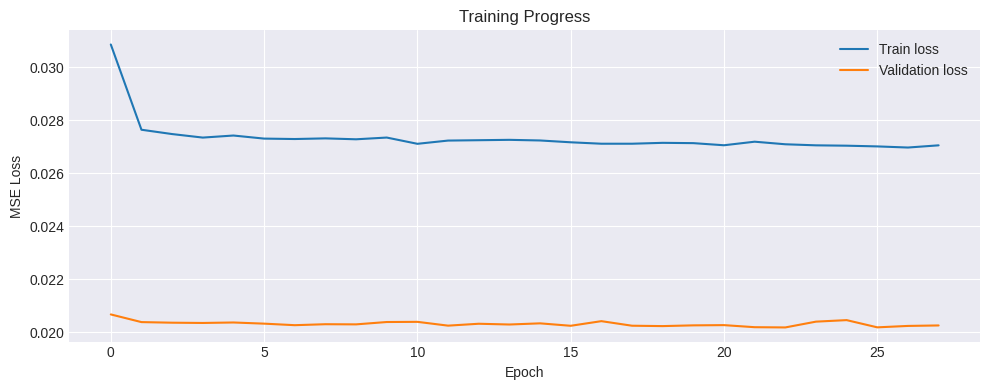

In [13]:
# Plot the training curves
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title("Training Progress")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

# 8. Making Predictions & Evaluating

We'll now predict on the test set and compare against the truth.

**Important:** our model outputs **scaled** prices. We need to **inverse-transform**
them back to real dollars using the same scaler.

### The metrics we'll look at

- **RMSE** — root mean squared error, in dollars
- **MAE** — mean absolute error, in dollars
- **MAPE** — mean absolute percentage error, scale-free

### The metric that *really* matters

**Directional accuracy** — did the model get the *direction* right?
If tomorrow is up, did we say up? A low RMSE but 50% directional accuracy
means the model is useless — it just memorized "tomorrow ≈ today".

In [14]:
# Predict scaled log-returns
pred_scaled  = model.predict(X_test, verbose=0)
pred_returns = scaler.inverse_transform(pred_scaled).flatten()

# Reconstruct prices:  price[t] = price[t-1] * exp(log_return[t])
close_prices = df['Close'].values

# For each test sample k, the "previous close" is the last value of its
# 60-day window — which is close[split_row + k - 1]
prev_close    = close_prices[split_row - 1 : split_row - 1 + len(pred_returns)]
actual_prices = close_prices[split_row     : split_row     + len(pred_returns)]

pred_prices = prev_close * np.exp(pred_returns)

# Metrics on prices (so they're comparable to the old numbers)
rmse = np.sqrt(mean_squared_error(actual_prices, pred_prices))
mae  = mean_absolute_error(actual_prices, pred_prices)
mape = np.mean(np.abs((actual_prices - pred_prices) / actual_prices)) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

RMSE: 9.39
MAE : 6.86
MAPE: 2.89%


In [15]:
# Direction — the metric that actually matters for trading
actual_dir = np.sign(np.diff(actual_prices))
pred_dir   = np.sign(np.diff(pred_prices))
dir_acc    = np.mean(actual_dir == pred_dir) * 100

# Naive baseline (tomorrow = today) for a fair comparison
naive_rmse = np.sqrt(mean_squared_error(actual_prices[1:], actual_prices[:-1]))
naive_mape = np.mean(
    np.abs((actual_prices[1:] - actual_prices[:-1]) / actual_prices[1:])
) * 100

print("┌──────────────────┬──────────┬──────────┐")
print("│ Model            │ RMSE     │ MAPE     │")
print("├──────────────────┼──────────┼──────────┤")
print(f"│ LSTM             │ {rmse:>7.2f}  │ {mape:>6.2f}%  │")
print(f"│ Naive (t = t-1)  │ {naive_rmse:>7.2f}  │ {naive_mape:>6.2f}%  │")
print("└──────────────────┴──────────┴──────────┘")
print(f"\n🎯 Directional accuracy: {dir_acc:.2f}%")
print("   (50% = coin flip, 55%+ = useful)")

┌──────────────────┬──────────┬──────────┐
│ Model            │ RMSE     │ MAPE     │
├──────────────────┼──────────┼──────────┤
│ LSTM             │    9.39  │   2.89%  │
│ Naive (t = t-1)  │    9.36  │   2.89%  │
└──────────────────┴──────────┴──────────┘

🎯 Directional accuracy: 52.19%
   (50% = coin flip, 55%+ = useful)


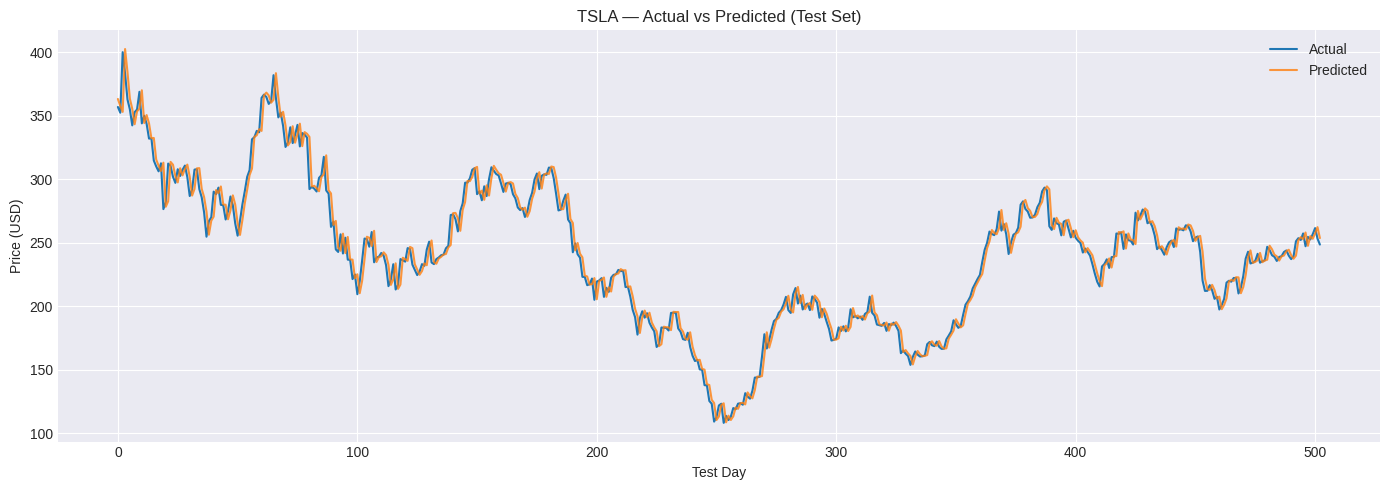

In [16]:
# Plot predicted vs actual
plt.figure(figsize=(14, 5))
plt.plot(actual_prices, label='Actual',    linewidth=1.5)
plt.plot(pred_prices,   label='Predicted', linewidth=1.5, alpha=0.8)
plt.title(f"{TICKER} — Actual vs Predicted (Test Set)")
plt.xlabel("Test Day")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()